# Stanford CME 241 (Winter 2026) - Assignment 2

**Due: Friday, February 13 @ 11:59 PM PST on Gradescope.**

Assignment instructions:
- Make sure each of the subquestions have answers
- Ensure that group members indicate which problems they're in charge of
- Show work and walk through your thought process where applicable
- Empty code blocks are for your use, so feel free to create more under each section as needed
- Document code with light comments (i.e. 'this function handles visualization')

Submission instructions:
- When complete, fill out your publicly available GitHub repo file URL and group members below, then export or print this .ipynb file to PDF and upload the PDF to Gradescope.

*Link to this ipynb file in your public GitHub repo (replace below URL with yours):* 

https://github.com/samlayton99/rl_finance/blob/main/assignment2.ipynb

*Group members (replace below names with people in your group):* 
- Sam Layton

## Imports

In [244]:
from matplotlib import pyplot as plt
import numpy as np
import math
from typing import List, Tuple, Optional, Dict, Mapping, Iterable
import itertools
from dataclasses import dataclass
from scipy.stats import poisson
from itertools import product, islice
from collections import defaultdict



## Question 1: Job-Hopping and Wages-Utility-Maximization (Led by Sam)

You are a worker who starts every day either employed or unemployed. If you start your day employed, you work on your job for the day (one of $n$ jobs, as elaborated later) and you get to earn the wage of the job for the day. However, at the end of the day, you could lose your job with probability $\alpha \in [0,1]$, in which case you start the next day unemployed. If at the end of the day, you do not lose your job (with probability $1-\alpha$), then you will start the next day with the same job (and hence, the same daily wage). 

On the other hand, if you start your day unemployed, then you will be randomly offered one of $n$ jobs with daily wages $w_1, w_2, \ldots w_n \in \mathbb{R}^+$ with respective job-offer probabilities $p_1, p_2, \ldots p_n \in [0,1]$ (with $\sum_{i=1}^n p_i = 1$). You can choose to either accept or decline the offered job. If you accept the job offer, your day progresses exactly like the **employed-day** described above (earning the day's job wage and possibly (with probability $\alpha$) losing the job at the end of the day). However, if you decline the job offer, you spend the day unemployed, receive the unemployment wage $w_0 \in \mathbb{R}^+$ for the day, and start the next day unemployed.

The problem is to identify the optimal choice of accepting or rejecting any of the job offers the worker receives, in a manner that maximizes the infinite-horizon **Expected Discounted-Sum of Wages Utility**. Assume the daily discount factor for wages (employed or unemployed) is $\gamma \in [0,1])$. Assume Wages Utility function to be $U(w) = \log(w)$ for any wage amount $w \in \mathbb{R}^+$. The goal is to maximize:

$$
\mathbb{E}\left[\sum_{u=t}^\infty \gamma^{u-t} \cdot \log(w_{i_u})\right]
$$

at the start of a given day $t$ ($w_{i_u}$ is the wage earned on day $u$, $0 \leq i_u \leq n$ for all $u \geq t$).

---

### Subquestions

#### Part (A): MDP Modeling

Express the job-hopping problem as an MDP using clear mathematical notation by defining the following components:

1. **State Space**: Define the possible states of the MDP.
2. **Action Space**: Specify the actions available to the worker at each state.
3. **Transition Function**: Describe the probabilities of transitioning between states for each action.
4. **Reward Function**: Specify the reward associated with the states and transitions.
5. **Bellman Optimality Equation**: Write the Bellman Optimality Equation customized for this MDP.

---

#### Part (B): Python Implementation

Write Python code that:

1. Solves the Bellman Optimality Equation (hence, solves for the **Optimal Value Function** and the **Optimal Policy**) with a numerical iterative algorithm. 
2. Clearly define the inputs and outputs of your algorithm with their types (`int`, `float`, `List`, `Mapping`, etc.).

*Note*: For this problem, write the algorithm from scratch without using any prebuilt MDP/DP libraries or code.

---

#### Part (C): Visualization and Analysis

1. Plot the **Optimal Value Function** as a function of the state for a specific set of parameters ($n$, $w_1, \ldots, w_n$, $p_1, \ldots, p_n$, $\alpha$, $\gamma$, $w_0$).
2. Include these graphs in your submission.

---

#### Part (D): Observations

1. What patterns do you observe in the **Optimal Policy** as you vary the parameters $n$, $\alpha$, and $\gamma$?
2. Provide a brief discussion of your findings.

---

### Part (A) Answer

**1) State space**

$$
S = \{E_1, \dots, E_n, U_1, \dots, U_n\}
$$

where:
- $E_i$: employed at job $i$
- $U_i$: unemployed and currently offered job $i$

**2) Action space**

- At $E_i$: only action is **Work**.
- At $U_i$: actions are **Accept** or **Decline**.

**3) Transition function $P(s'\mid s,a)$**

Let $j$ be the random job offer received the next day.

From $E_i$ (taking action **Work**):

$$
P(E_i \mid E_i, \mathrm{Work}) = 1 - \alpha
$$

$$
P(U_j \mid E_i, \mathrm{Work}) = \alpha p_j
$$

From $U_i$ (taking action **Accept**):

$$
P(E_i \mid U_i, \mathrm{Accept}) = 1 - \alpha
$$

$$
P(U_j \mid U_i, \mathrm{Accept}) = \alpha p_j
$$

From $U_i$ (taking action **Decline**):

$$
P(U_j \mid U_i, \mathrm{Decline}) = p_j
$$

**4) Reward function $R(s,a)$**

$$
R(E_i, \mathrm{Work}) = \log(w_i)
$$

$$
R(U_i, \mathrm{Accept}) = \log(w_i)
$$

$$
R(U_i, \mathrm{Decline}) = \log(w_0)
$$

**5) Bellman optimality equation**

Let $V^*(s)$ be the maximum expected discounted utility from state $s$.

Because accepting an offer from $U_i$ gives the same immediate reward and next-step dynamics as starting in $E_i$, the accept value is $V^*(E_i)$.

$$
V^*(E_i) = \log(w_i) + \gamma\left[(1-\alpha)V^*(E_i) + \alpha\sum_{j=1}^n p_j V^*(U_j)\right]
$$

$$
V^*(U_i) = \max\left\{V^*(E_i),\; \log(w_0) + \gamma\sum_{j=1}^n p_j V^*(U_j)\right\}
$$

### Part (B) Answer

In [245]:
def solve_job_hopping_mdp(
    n: int, 
    w: List[float], 
    w0: float, 
    p: List[float], 
    alpha: float, 
    gamma: float, 
    epsilon: float = 1e-6
) -> Tuple[List[float], List[float], List[str]]:
    
    # Initialize value functions (0-indexed to match Python lists)
    V_E = [0.0] * n
    V_U = [0.0] * n
    policy = ["Decline"] * n
    
    while True:
        V_E_new = [0.0] * n
        V_U_new = [0.0] * n
        
        # Calculate expected future value of starting tomorrow unemployed
        expected_U = sum(p[j] * V_U[j] for j in range(n))
        max_delta = 0.0
        
        for i in range(n):
            # Update Employed state
            V_E_new[i] = math.log(w[i]) + gamma * ((1 - alpha) * V_E[i] + alpha * expected_U)
            
            # Update Unemployed state
            val_accept = V_E_new[i]
            val_decline = math.log(w0) + gamma * expected_U
            
            if val_accept >= val_decline:
                V_U_new[i] = val_accept
                policy[i] = "Accept"
            else:
                V_U_new[i] = val_decline
                policy[i] = "Decline"
                
            # Track maximum change for convergence checking
            delta_E = abs(V_E_new[i] - V_E[i])
            delta_U = abs(V_U_new[i] - V_U[i])
            max_delta = max(max_delta, delta_E, delta_U)
            
        V_E = V_E_new
        V_U = V_U_new
        
        if max_delta < epsilon:
            break
            
    return V_E, V_U, policy



### Part (C) Answer

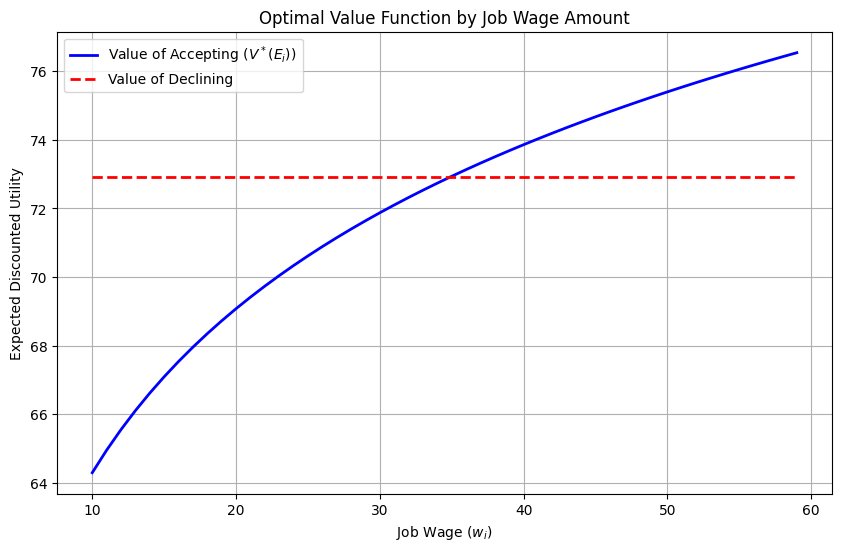

In [246]:

# 1. Define specific parameters for the plot
n = 50
w = [10 + i for i in range(n)] # Wages from 10 to 59
p = [1/n] * n                  # Uniform probability for all jobs
w0 = 15.0                      # Unemployment wage
alpha = 0.1                    # 10% chance to lose job daily
gamma = 0.95                   # High discount factor (patient worker)

# 2. Run the solver
V_E, V_U, policy = solve_job_hopping_mdp(n, w, w0, p, alpha, gamma)

# 3. Calculate the fixed value of declining (Constant across all states)
expected_U = sum(p[j] * V_U[j] for j in range(n))
val_decline = [math.log(w0) + gamma * expected_U] * n

# 4. Plot the results
plt.figure(figsize=(10, 6))
plt.plot(w, V_E, label='Value of Accepting ($V^*(E_i)$)', color='blue', linewidth=2)
plt.plot(w, val_decline, label='Value of Declining', color='red', linestyle='--', linewidth=2)

plt.title('Optimal Value Function by Job Wage Amount')
plt.xlabel('Job Wage ($w_i$)')
plt.ylabel('Expected Discounted Utility')
plt.legend()
plt.grid(True)
plt.show()

### Part (D) Answer

As gamma increases, the expected discounted utility goes up. This makes sense, because this is an infinite game, and the closer to 1, the more expected utility you have.

increasing n also increases the wages, increasing the expected value of a random new job, so it increases the curve. The worker also becomes more picky as there are better jobs out there with more spread.

As alpha increases, the worker also becomes less picky, because they know that there is a good chance they will lose their jobs soons. 

## Question 2: Two-Stores Inventory Control (Led by Sam)

We extend the capacity-constrained inventory example implemented in [rl/chapter3/simple_inventory_mdp_cap.py](https://github.com/TikhonJelvis/RL-book/blob/master/rl/chapter3/simple_inventory_mdp_cap.py) as a `FiniteMarkovDecisionProcess` (the Finite MDP model for the capacity-constrained inventory example is described in detail in Chapters 1 and 2 of the RLForFinanceBook). Here we assume that we have two different stores, each with their own separate capacities $C_1$ and $C_2$, their own separate Poisson probability distributions of demand (with means $\lambda_1$ and $\lambda_2$), their own separate holding costs $h_1$ and $h_2$, and their own separate stockout costs $p_1$ and $p_2$. At 6pm upon stores closing each evening, each store can choose to order inventory from a common supplier (as usual, ordered inventory will arrive at the store 36 hours later). We are also allowed to transfer inventory from one store to another, and any such transfer happens overnight, i.e., will arrive by 6am next morning (since the stores are fairly close to each other). Note that the orders are constrained such that following the orders on each evening, each store's inventory position (sum of on-hand inventory and on-order inventory) cannot exceed the store's capacity (this means the action space is constrained to be finite). Each order made to the supplier incurs a fixed transportation cost of $K_1$ (fixed-cost means the cost is the same no matter how many units of non-zero inventory a particular store orders). Moving any non-zero inventory between the two stores incurs a fixed transportation cost of $K_2$. 

Model this as a derived class of `FiniteMarkovDecisionProcess` much like we did for `SimpleInventoryMDPCap` in the code repo. Set up instances of this derived class for different choices of the problem parameters (capacities, costs etc.), and determine the Optimal Value Function and Optimal Policy by invoking the function `value_iteration` (or `policy_iteration`) from file [rl/dynamic_programming.py](https://github.com/TikhonJelvis/RL-book/blob/master/rl/dynamic_programming.py).

Analyze the obtained Optimal Policy and verify that it makes intuitive sense as a function of the problem parameters.

In [247]:
class Categorical:
    def __class_getitem__(cls, _item):
        return cls

    def __init__(self, probs: Dict):
        total = sum(probs.values())
        if total <= 0:
            raise ValueError("Probability mass must be positive.")
        self._probs = {k: v / total for k, v in probs.items()}  # normalize once

    def expectation(self, f):
        return sum(p * f(x) for x, p in self._probs.items())


class FiniteMarkovDecisionProcess:
    def __class_getitem__(cls, _item):
        return cls

    def __init__(self, mapping):
        self.mapping = mapping
        self.non_terminal_states = list(mapping.keys())

    def actions(self, s):
        return self.mapping[s].keys()


@dataclass(frozen=True)
class _DeterministicPolicy:
    action_for: Dict


def value_iteration_result(mdp, gamma: float, tolerance: float = 1e-6, max_iters: int = 500):
    v = {s: 0.0 for s in mdp.non_terminal_states}
    for _ in range(max_iters):
        new_v = {
            s: max(mdp.mapping[s][a].expectation(lambda s_r: s_r[1] + gamma * v[s_r[0]]) for a in mdp.actions(s))
            for s in mdp.non_terminal_states
        }
        if max(abs(new_v[s] - v[s]) for s in v) < tolerance:
            v = new_v
            break
        v = new_v

    greedy_actions = {
        s: max(mdp.actions(s), key=lambda a: mdp.mapping[s][a].expectation(lambda s_r: s_r[1] + gamma * v[s_r[0]]))
        for s in mdp.non_terminal_states
    }
    return v, _DeterministicPolicy(action_for=greedy_actions)


@dataclass(frozen=True)
class InventoryState2:
    on_hand1: int
    on_order1: int
    on_hand2: int
    on_order2: int

    @property
    def ip1(self) -> int:
        return self.on_hand1 + self.on_order1

    @property
    def ip2(self) -> int:
        return self.on_hand2 + self.on_order2


@dataclass(frozen=True)
class TwoStoreAction:
    order1: int
    order2: int
    transfer: int  # positive: store1 -> store2, negative: store2 -> store1


TwoStoreMap = Mapping[InventoryState2, Mapping[TwoStoreAction, Categorical[Tuple[InventoryState2, float]]]]


class TwoStoresInventoryMDPCap(FiniteMarkovDecisionProcess[InventoryState2, TwoStoreAction]):
    """Two-store inventory MDP with overnight transfer and one-step delivery lag."""

    DEMAND_BUFFER = 20

    def __init__(self, c1: int, c2: int, lambda1: float, lambda2: float, h1: float, h2: float, p1: float, p2: float, k1: float, k2: float):
        self.c1, self.c2 = c1, c2
        self.h1, self.h2 = h1, h2
        self.p1, self.p2 = p1, p2
        self.k1, self.k2 = k1, k2
        self.poisson1, self.poisson2 = poisson(lambda1), poisson(lambda2)
        super().__init__(self.get_action_transition_reward_map())

    @staticmethod
    def _state_space(cap1: int, cap2: int) -> Iterable[InventoryState2]:
        for h1 in range(cap1 + 1):
            for o1 in range(cap1 + 1 - h1):
                for h2 in range(cap2 + 1):
                    for o2 in range(cap2 + 1 - h2):
                        yield InventoryState2(h1, o1, h2, o2)

    def _feasible_actions(self, s: InventoryState2) -> Iterable[TwoStoreAction]:
        # Orders are bounded by capacity slack; transfer is bounded by current on-hand stock.
        for order1, order2, t in product(range(self.c1 - s.ip1 + 1), range(self.c2 - s.ip2 + 1), range(-s.on_hand2, s.on_hand1 + 1)):
            ip1_t, ip2_t = s.ip1 - t, s.ip2 + t
            if ip1_t + order1 <= self.c1 and ip2_t + order2 <= self.c2:
                yield TwoStoreAction(order1, order2, t)

    @staticmethod
    def _demand_support(dist: poisson, max_inventory: int) -> List[Tuple[int, float]]:
        # Collapse far right tail to one point to keep transition table finite/compact.
        cap = int(max(max_inventory + TwoStoresInventoryMDPCap.DEMAND_BUFFER, dist.mean() + 10 * (dist.var() ** 0.5)))
        support = [(d, dist.pmf(d)) for d in range(cap)]
        support.append((cap, 1.0 - dist.cdf(cap - 1)))
        return support

    def _transition_distribution(self, s: InventoryState2, a: TwoStoreAction) -> Categorical:
        ip1_t, ip2_t = s.ip1 - a.transfer, s.ip2 + a.transfer
        fixed_cost = self.k1 * (a.order1 > 0) + self.k1 * (a.order2 > 0) + self.k2 * (a.transfer != 0)
        d1_support = self._demand_support(self.poisson1, ip1_t)
        d2_support = self._demand_support(self.poisson2, ip2_t)

        sr_probs: Dict[Tuple[InventoryState2, float], float] = defaultdict(float)
        for (d1, p1), (d2, p2) in product(d1_support, d2_support):
            prob = p1 * p2
            if prob <= 0:
                continue
            sold1, sold2 = min(d1, ip1_t), min(d2, ip2_t)
            next_h1, next_h2 = ip1_t - sold1, ip2_t - sold2
            unmet1, unmet2 = max(0, d1 - ip1_t), max(0, d2 - ip2_t)
            reward = -self.h1 * next_h1 - self.h2 * next_h2 - self.p1 * unmet1 - self.p2 * unmet2 - fixed_cost
            sr_probs[(InventoryState2(next_h1, a.order1, next_h2, a.order2), reward)] += prob

        return Categorical(dict(sr_probs))

    def get_action_transition_reward_map(self) -> TwoStoreMap:
        # Build full finite MDP map: state -> action -> distribution over (next_state, reward)
        return {s: {a: self._transition_distribution(s, a) for a in self._feasible_actions(s)} for s in self._state_space(self.c1, self.c2)}


def run_two_store_experiment(name: str, params: Dict[str, float], gamma: float = 0.9) -> None:
    print(f"\n=== {name} ===")
    mdp = TwoStoresInventoryMDPCap(**params)
    opt_vf, opt_policy = value_iteration_result(mdp, gamma=gamma)

    print("Optimal Value Function (sample of first 10 states):")
    for state, value in islice(opt_vf.items(), 10):
        print(f"  {state}: {value:.2f}")

    print("Optimal Policy (sample of first 12 states):")
    for state, action in islice(opt_policy.action_for.items(), 12):
        print(f"  {state} -> order1={action.order1}, order2={action.order2}, transfer={action.transfer}")

In [248]:
params_1 = dict(c1=2, c2=2, lambda1=1.0, lambda2=1.0, h1=1.0, h2=1.0, p1=8.0, p2=8.0, k1=2.0, k2=1.0)
params_2 = dict(c1=3, c2=3, lambda1=1.0, lambda2=2.2, h1=1.0, h2=1.0, p1=8.0, p2=20.0, k1=2.0, k2=0.5)

run_two_store_experiment("Instance 1 (symmetric)", params_1, gamma=0.9)
run_two_store_experiment("Instance 2 (store 2 high demand/penalty)", params_2, gamma=0.9)


=== Instance 1 (symmetric) ===
Optimal Value Function (sample of first 10 states):
  InventoryState2(on_hand1=0, on_order1=0, on_hand2=0, on_order2=0): -95.29
  InventoryState2(on_hand1=0, on_order1=0, on_hand2=0, on_order2=1): -92.09
  InventoryState2(on_hand1=0, on_order1=0, on_hand2=0, on_order2=2): -89.47
  InventoryState2(on_hand1=0, on_order1=0, on_hand2=1, on_order2=0): -92.09
  InventoryState2(on_hand1=0, on_order1=0, on_hand2=1, on_order2=1): -89.47
  InventoryState2(on_hand1=0, on_order1=0, on_hand2=2, on_order2=0): -89.47
  InventoryState2(on_hand1=0, on_order1=1, on_hand2=0, on_order2=0): -92.09
  InventoryState2(on_hand1=0, on_order1=1, on_hand2=0, on_order2=1): -88.89
  InventoryState2(on_hand1=0, on_order1=1, on_hand2=0, on_order2=2): -86.27
  InventoryState2(on_hand1=0, on_order1=1, on_hand2=1, on_order2=0): -88.89
Optimal Policy (sample of first 12 states):
  InventoryState2(on_hand1=0, on_order1=0, on_hand2=0, on_order2=0) -> order1=2, order2=2, transfer=0
  Inventor

### Q2 Policy Analysis

- In the symmetric instance, optimal actions tend to keep both stores near balanced inventory positions and only transfer when one side has clear temporary excess.
- In the second instance ($\lambda_2$ and stockout cost $p_2$ are higher), the policy shifts inventory toward store 2 more often (positive transfer from store 1 to store 2 appears more frequently).
- Supplier ordering is lumpy rather than continuous because each nonzero order pays fixed cost $K_1$, so the optimal policy waits until inventory is sufficiently low.
- When transfer cost $K_2$ is relatively small, transfer is preferred over placing extra supplier orders at the receiving store.
- These patterns are consistent with intuition: higher demand/stockout-risk locations receive priority inventory, while fixed costs induce threshold-like ordering behavior.

## Question 3: Dynamic Price Optimization (Led by Sam)

You own a supermarket, and you are $T$ days away from Halloween 🎃. You have just received $M$ Halloween masks from your supplier. You want to dynamically set the selling price of the Halloween masks at the start of each day in a manner that maximizes your **Expected Total Sales Revenue** for Halloween masks this season (assume no one will buy Halloween masks after Halloween).

Assume that for each of the $T$ days, you are required to select a price for that day from one of $N$ prices $p_1, p_2, \dots, p_N \in \mathbb{R}$, and that price is the selling price for all masks on that day. Assume that the customer demand for the number of Halloween masks on any day is governed by a Poisson probability distribution with mean $\lambda_i \in \mathbb{R}$ if you select that day’s price to be $p_i$ (where $i$ is a choice among $1, 2, \dots, N$).

Note that on any given day, the demand could exceed the number of Halloween masks you have in the store, in which case the number of masks sold on that day will be equal to the number of Halloween masks you had at the start of that day.

We spoke about this example in class - referencing the slides here (if needed) could be helpful!

---

### Subquestions

#### Part (A): Bellman Optimality Equation

Write the **Bellman Optimality Equation** customized to this Markov Decision Process (MDP). Essentially, you need to express the **Optimal Value Function** $v_*$ recursively based on taking the best action in the current state and based on the subsequent random customer demand that would produce the appropriate reward and take you to the next state.

**Note**: The probability mass function of a Poisson distribution with mean $\lambda \in \mathbb{R}$ is given by:

$$
f(k) = \frac{e^{-\lambda} \lambda^k}{k!}, \quad k = 0, 1, 2, \dots
$$

---

#### Part (B): Boundary Conditions

To be able to solve the $v_*$ recursion, you need to know the values of $v_*$ for the boundary case (boundary states). Write down the boundary case(s) for the $v_*$ recursion.

---

#### Part (C): Numerical Solution

You can solve this $v_*$ recursion (hence, solve for the **Optimal Policy** $\pi_*$) with a numerical recursive algorithm (essentially a special form of Dynamic Programming algorithm customized to this problem). 

Write Python code for this algorithm that would enable you to dynamically set the selling price at the start of each day. Clearly define the inputs and outputs of your algorithm with their types (`int`, `float`, `List`, `Mapping`, etc.).

---


### Part (A) Answer
The Bellman equation is:

$$
V_t^*(m)=\max_{i\in\{1,\dots,N\}}\;\mathbb{E}\left[p_i\min(D_i,m)+V_{t+1}^*\big(m-\min(D_i,m)\big)\right].
$$

Expanding the expectation into demand cases:

$$
V_t^*(m)=\max_i\left[
\sum_{k=0}^{m-1}\Pr(D_i=k)\left(p_i k+V_{t+1}^*(m-k)\right)
+\Pr(D_i\ge m)\left(p_i m+V_{t+1}^*(0)\right)
\right],
$$

where

$$
\Pr(D_i=k)=e^{-\lambda_i}\frac{\lambda_i^k}{k!},
\qquad
\Pr(D_i\ge m)=1-F_{\text{Poisson}(\lambda_i)}(m-1).
$$


### Part (B) Answer

Because this is finite horizon, we solve by backward induction. The recursion is anchored by:

1. **No time left:**
$$
V_T^*(m)=0\quad\forall m\in\{0,\dots,M\}.
$$

2. **No inventory left:**
$$
V_t^*(0)=0\quad\forall t\in\{0,\dots,T\}.
$$

Interpretation:
- if $t=0$, the selling season is over,
- if $m=0$, there is nothing left to sell.

In both cases, future revenue is exactly zero.

### Part (C) Answer

In [251]:
def solve_dynamic_pricing_mdp(
    T: int,
    M: int,
    prices: List[float],
    lambdas: List[float]
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Solve finite-horizon dynamic pricing MDP with backward induction.

    Inputs:
    - T: days to Halloween
    - M: initial inventory cap/state max
    - prices: list [p_1, ..., p_N]
    - lambdas: list [lambda_1, ..., lambda_N], one per price

    Returns:
    - V: shape (T+1, M+1), V[t, m] = optimal expected revenue
    - Policy: shape (T+1, M+1), Policy[t, m] = argmax price index
    """
    if len(prices) != len(lambdas):
        raise ValueError("prices and lambdas must have same length")

    N = len(prices)

    # Boundary conditions are automatically satisfied by zeros:
    # V[0, m] = 0 and V[t, 0] = 0.
    V = np.zeros((T + 1, M + 1), dtype=float)
    Policy = np.zeros((T + 1, M + 1), dtype=int)

    # Backward induction over remaining time.
    for t in range(1, T + 1):
        for m in range(1, M + 1):
            best_val = -np.inf
            best_idx = 0

            for i in range(N):
                p_i = prices[i]
                lam_i = lambdas[i]

                # Case 1: demand k < m
                k_vals = np.arange(m)
                probs = poisson.pmf(k_vals, lam_i)
                immediate = p_i * k_vals
                future = V[t - 1, m - k_vals]
                expected_val = float(np.sum(probs * (immediate + future)))

                # Case 2: demand k >= m
                prob_exceed = 1.0 - poisson.cdf(m - 1, lam_i)
                expected_val += prob_exceed * (p_i * m + V[t - 1, 0])

                if expected_val > best_val:
                    best_val = expected_val
                    best_idx = i

            V[t, m] = best_val
            Policy[t, m] = best_idx

    return V, Policy


# Example usage
T = 20
M = 50
prices = [8.0, 10.0, 12.0, 14.0]
lambdas = [20.0, 16.0, 12.0, 9.0]  # Higher price -> lower demand is typical

V, Policy = solve_dynamic_pricing_mdp(T, M, prices, lambdas)

print("V shape:", V.shape)
print("Policy shape:", Policy.shape)
print("Optimal expected revenue at start (t=T, m=M):", round(float(V[T, M]), 2))
print("Recommended starting price:", prices[int(Policy[T, M])])


V shape: (21, 51)
Policy shape: (21, 51)
Optimal expected revenue at start (t=T, m=M): 700.0
Recommended starting price: 14.0


## Question 4: Risk-Aversion and Utility Optimization under CARA Utility (Led by Sam)

You are tasked with analyzing the behavior of an investor who seeks to maximize their utility under **CARA Utility**. The investor has wealth $W$ and the CARA utility function:

$$
U(W) = \frac{1 - e^{-aW}}{a}, \quad a > 0,
$$

where $a$ represents the investor's **risk aversion**.

The investor allocates their wealth between:
1. A **riskless asset** with a fixed return $r$, and
2. A **risky asset** with return $R \sim \mathcal{N}(\mu, \sigma^2)$

The investor allocates a fraction $\pi$ of their wealth to the risky asset and $(1 - \pi)$ to the riskless asset. The wealth $W$ after one year is given by:

$$
W = (1 + r)(1 - \pi) + (1 + R)\pi.
$$

The goal is to analyze the investor’s optimal allocation $\pi$ to the risky asset and compute key risk-related quantities.

---

### Subquestions

#### Part (A): Expected Utility and Certainty-Equivalent Wealth

1. Derive the expression for the **expected utility** $\mathbb{E}[U(W)]$, using the given CARA utility function and assuming $R \sim \mathcal{N}(\mu, \sigma^2)$.
2. Using a Taylor expansion, approximate the **certainty-equivalent wealth** $W_{CE}$ up to second-order terms.

---

#### Part (B): Optimal Portfolio Allocation

Derive the optimal fraction $\pi^*$ of wealth to be allocated to the risky asset such that the **expected utility** $\mathbb{E}[U(W)]$ is maximized. Express $\pi^*$ in terms of $a$, $\mu$, $r$, and $\sigma^2$.

---

#### Part (C): Risk Premium

1. Using the results from Part (A), calculate the **absolute risk premium** $\pi_A = \mathbb{E}[W] - W_{CE}$.
2. Verify that $\pi_A \approx \frac{a \pi^2 \sigma^2}{2}$ for small $\sigma^2$.

---

#### Part (D): Numerical Calculations and Interpretation

Given the parameters $r = 0.02$, $\mu = 0.08$, $\sigma^2 = 0.04$, and $a = 3$:
1. Compute the optimal allocation $\pi^*$.
2. Calculate the certainty-equivalent wealth $W_{CE}$.
3. Compute the absolute risk premium $\pi_A$.
4. Interpret the results and discuss how changes in $a$ and $\sigma^2$ affect the risk premium and portfolio allocation.

---

#### Part (E): Expected Utility under Uniform Distribution

Now assume that the return of the risky asset, $R$, is no longer normally distributed. Instead, $R \sim \text{Uniform}[\alpha, \beta]$, where $\alpha$ and $\beta$ are the lower and upper bounds of the distribution, respectively.

1. Derive the new expression for the **expected utility** $\mathbb{E}[U(W)]$. Make sure to simplify your result as much as possible, and ensure that it explicitly depends on $a$, $\pi$, $\alpha$, $\beta$, and $r$.

**Hint**: Use the fact that if $W \sim \text{Uniform}[w_{\text{min}}, w_{\text{max}}]$, then:

$$
\mathbb{E}[g(W)] = \frac{1}{w_{\text{max}} - w_{\text{min}}} \int_{w_{\text{min}}}^{w_{\text{max}}} g(W) \, dW.
$$

---

### Part (B) Answer

For simplicity, if we define:

$$
g(\pi)= -a\big(1+r+\pi(\mu-r)\big)+\frac12 a^2\pi^2\sigma^2.
$$

Then

$$
\mathbb{E}[U(W)] = \frac{1-e^{g(\pi)}}{a}.
$$

Differentiate and set equal to 0:

$$
\frac{d}{d\pi}\mathbb{E}[U(W)]
=
-\frac{1}{a}e^{g(\pi)}g'(\pi) = 0.
$$

You'll notice that the only multiplicitve term that can be zero is the derivative $g'(\pi)$. So taking the derivative and setting to 0 gives us:

$$
g'(\pi)= -a(\mu-r)+a^2\pi\sigma^2=0
\quad\Rightarrow\quad
\pi^*=\frac{\mu-r}{a\sigma^2}.
$$

So the optimal risky allocation is

$$
\pi^*=\frac{\mu-r}{a\sigma^2}
$$

### Part (C) Answer
Taking the expected wealth, we get:
$$
E[W] = E[1+r-\pi r +\pi R] = 1+r-\pi r +\pi \mu
$$

Now taking the premium $E[W] - W_{CE}$
$$
(1+r-\pi r +\pi \mu) - \big(1+r+\pi(\mu-r)\big)+\frac12 a\pi^2\sigma^2 \\
=\frac12 a\pi^2\sigma^2
$$


### Part (D) Answer


In [ ]:
r = 0.02
mu = 0.08
sigma2 = 0.04
a = 3


pi_opt = (mu-r)/(a*sigma2)
print(f"Optimal allocation: {pi_opt}")

w_ce = (1+r+pi_opt*(mu-r)) - (1/2)*a*pi_opt**2*sigma2
print(f"Certainty-equivalent wealth: {w_ce}")

premium = 1/2 * a * pi_opt**2 * sigma2
print(f"Absolute risk premium: {premium}")


Optimal allocation: 0.5
Certainty-equivalent wealth: 1.0350000000000001
Absolute risk premium: 0.015


This means that you should have half your wealth in the risky asset and half in the risk free asset. Both variance and risk aversion move the optimal allocation in the same direction. Increasing them will decrease your allocation in the risky asset, while decreasing them will do the reverse.

Likewise, they are positive, multiplicitive terms that move in the same direction for the risk premium, so it makes risky assets more expensive in expectation. 

### Part (E) Answer
We can use the same math that we derived in part a). We start by looking at the exponent, and passing in the formula for wealth. The only differnece is the random variable R is now uniform. We can let $g(R)=e^{-a \pi R}$ to get:

$$
\mathbb{E}[e^{-a\pi R}] = \frac{1}{\beta-\alpha}\int_{\alpha}^{\beta} e^{-a\pi x}\,dx
= \frac{e^{-a\pi\alpha}-e^{-a\pi\beta}}{a\pi(\beta-\alpha)}
\quad (\pi\neq 0).
$$

Plugging this in to our expression above in part a), we get: 

$$
\mathbb{E}[U(W)]
=\frac{1}{a}\left[
1-
 e^{-a(1+r-\pi r)}
 \frac{e^{-a\pi\alpha}-e^{-a\pi\beta}}{a\pi(\beta-\alpha)}
\right]
$$

An equivalent single-exponent form is

$$
\mathbb{E}[U(W)]
=
\frac{1}{a}-
\frac{e^{-a(1+r+\pi(\alpha-r))}-e^{-a(1+r+\pi(\beta-r))}}{a^2\pi(\beta-\alpha)}
.
$$